In [41]:
import uproot 
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd
import seaborn as sns
import plotly.express as px


In [42]:
total_keys = ['Jpsi_PT', 'L_END_VRHO', 'L_BPVDIRA', 'L_BPVIP', 'L_BPVIPCHI2',
       'Lb_BPVDIRA', 'Lb_BPVIP', 'Lb_BPVVDRHO', 'Lb_MAXDOCA', 'Lb_P', 'Lb_PT',
       'Lb_CHI2', 'p_PID_P', 'p_MINIP', 'mup_PID_MU', 'L_PT', 'Jpsi_MAXDOCA',
       'Lb_MINIPCHI2', 'L_P', 'Jpsi_BPVDIRA', 'L_CHI2', 'Lb_ETA', 'L_END_VZ',
       'L_END_VX', 'L_END_VY', 'Jpsi_ETA', 'p_P', 'p_PT', 'p_ETA',
       'p_GHOSTPROB', 'pim_P', 'pim_PT', 'pim_ETA', 'pim_GHOSTPROB']

preslectrion_keys = ['SUMCHI2','Cos_xi_LbP','Cos_xi_LP','xi_LbP', 'xi_LP' ] # ,'xi_LbP', 'xi_LP' 



training_variables = total_keys+preslectrion_keys

In [43]:
# preselection_cut = '(Jpsi_P > 10000) & (mup_PID_MU > 0) & (mum_PID_MU > 0) & (Jpsi_MAXDOCA < 0.15) & (p_PID_P > 0) & ( p_P > 10000)& ( p_PT > 400) & ( pim_P > 2000) & (L_PT > 450) & (Lb_CHI2 < 150) & (L_MASS < 1500) & (L_MASS > 950) & (Jpsi_CHI2 < 4 ) &  (L_CHI2 < 100) & (L_END_VZ > 5000) '
# preselection_cut_mc = '(Jpsi_P > 10000) & (mup_PID_MU > 0) & (mum_PID_MU > 0) & (Jpsi_MAXDOCA < 0.15) & (p_PID_P > 0) & ( p_P > 10000)& ( p_PT > 400) & ( pim_P > 2000) & (L_PT > 450) & (Lb_CHI2 < 150) & (L_MASS < 1500) & (L_MASS > 950) & (Jpsi_CHI2 < 4 ) &  (L_CHI2 < 100) & (L_END_VZ > 5000) '
preselection_cut = '(Jpsi_P > 10000) & (mup_PID_MU > 0) & (mum_PID_MU > 0) & (Jpsi_MAXDOCA < 0.15) & (p_PID_P > 0) & ( p_P > 10000)& ( p_PT > 400) & ( pim_P > 2000) & (L_PT > 450) & (Lb_CHI2 < 150) & (L_MASS < 1500) & (L_MASS > 950) & (Jpsi_CHI2 < 4 ) &  (L_CHI2 < 100) '
preselection_cut_mc = '(Jpsi_P > 10000) & (mup_PID_MU > 0) & (mum_PID_MU > 0) & (Jpsi_MAXDOCA < 0.15) & (p_PID_P > 0) & ( p_P > 10000)& ( p_PT > 400) & ( pim_P > 2000) & (L_PT > 450) & (Lb_CHI2 < 150) & (L_MASS < 1500) & (L_MASS > 950) & (Jpsi_CHI2 < 4 ) &  (L_CHI2 < 100) '


second_cuts = '(Cos_xi_LP > 0.9999) & (Cos_xi_LbP > 0.99) & (pim_GHOSTPROB < 0.15) & (p_GHOSTPROB < 0.4) & (mum_GHOSTPROB < 0.4) & (mup_GHOSTPROB < 0.4) & (L_END_VZ > 5000) & (Jpsi_BPVDIRA > 0.999)& (Jpsi_MAXDOCA < 0.10)'
second_cuts_mc = '(Cos_xi_LP > 0.9999) & (Cos_xi_LbP > 0.99) & (pim_GHOSTPROB < 0.15) & (p_GHOSTPROB < 0.4) & (mum_GHOSTPROB < 0.4) & (mup_GHOSTPROB < 0.4) & (L_END_VZ > 5000) & (Jpsi_BPVDIRA > 0.999)& (Jpsi_MAXDOCA < 0.10)'

In [44]:
my_tuple_mc_1 = uproot.open("/l/izaac/data/24mc/jpsiLambda/mu/00225128_00000001_1.dvtuple.root:Hlt2BandQ_Lb2JpsiLambdaTT/DecayTree;1")
my_tuple_mc_2 = uproot.open("/l/izaac/data/24mc/jpsiLambda/mu/00225128_00000002_1.dvtuple.root:Hlt2BandQ_Lb2JpsiLambdaTT/DecayTree;1")
my_tuple_mc_3 = uproot.open("/l/izaac/data/24mc/jpsiLambda/md/00225126_00000001_1.dvtuple.root:Hlt2BandQ_Lb2JpsiLambdaTT/DecayTree")
my_tuple_mc_4 = uproot.open("/l/izaac/data/24mc/jpsiLambda/md/00225126_00000002_1.dvtuple.root:Hlt2BandQ_Lb2JpsiLambdaTT/DecayTree")

mc_data1 = my_tuple_mc_1.arrays(total_keys + ['Lb_BKGCAT'] + ['p_TRUEORIGIN_VZ'] + ['Jpsi_CHI2'] + ['p_PX'] + ['p_PY'] + ['p_PZ'] + ['L_PX'] + ['L_PY'] + ['L_PZ'] + ['Lb_PX'] + ['Lb_PY'] + ['Lb_PZ'] + ['Lb_MASS']+ ['EVENTNUMBER'] + ['Jpsi_P'] + ['mum_PID_MU'] + ['L_MASS'], library="pd", cut="(Lb_BKGCAT==0)&(p_TRUEORIGIN_VZ > 2500)")
mc_data2 = my_tuple_mc_2.arrays(total_keys + ['Lb_BKGCAT'] + ['p_TRUEORIGIN_VZ'] + ['Jpsi_CHI2'] + ['p_PX'] + ['p_PY'] + ['p_PZ'] + ['L_PX'] + ['L_PY'] + ['L_PZ'] + ['Lb_PX'] + ['Lb_PY'] + ['Lb_PZ']+ ['Lb_MASS']+ ['EVENTNUMBER'] + ['Jpsi_P'] + ['mum_PID_MU'] + ['L_MASS'],library="pd", cut="(Lb_BKGCAT==0)&(p_TRUEORIGIN_VZ > 2500)")
mc_data3 = my_tuple_mc_1.arrays(total_keys + ['Lb_BKGCAT'] + ['p_TRUEORIGIN_VZ'] + ['Jpsi_CHI2'] + ['p_PX'] + ['p_PY'] + ['p_PZ'] + ['L_PX'] + ['L_PY'] + ['L_PZ'] + ['Lb_PX'] + ['Lb_PY'] + ['Lb_PZ']+ ['Lb_MASS']+ ['EVENTNUMBER'] + ['Jpsi_P'] + ['mum_PID_MU'] + ['L_MASS'],library="pd", cut="(Lb_BKGCAT!=0)|(p_TRUEORIGIN_VZ < 2500)")
mc_data4 = my_tuple_mc_2.arrays(total_keys + ['Lb_BKGCAT'] + ['p_TRUEORIGIN_VZ'] + ['Jpsi_CHI2'] + ['p_PX'] + ['p_PY'] + ['p_PZ'] + ['L_PX'] + ['L_PY'] + ['L_PZ'] + ['Lb_PX'] + ['Lb_PY'] + ['Lb_PZ']+ ['Lb_MASS']+ ['EVENTNUMBER'] + ['Jpsi_P'] + ['mum_PID_MU'] + ['L_MASS'],library="pd", cut="(Lb_BKGCAT!=0)|(p_TRUEORIGIN_VZ < 2500)")

mc_data5 = my_tuple_mc_3.arrays(total_keys + ['Lb_BKGCAT'] + ['p_TRUEORIGIN_VZ'] + ['Jpsi_CHI2'] + ['p_PX'] + ['p_PY'] + ['p_PZ'] + ['L_PX'] + ['L_PY'] + ['L_PZ'] + ['Lb_PX'] + ['Lb_PY'] + ['Lb_PZ']+ ['Lb_MASS']+ ['EVENTNUMBER'] + ['Jpsi_P'] + ['mum_PID_MU'] + ['L_MASS'], library="pd", cut="(Lb_BKGCAT==0)&(p_TRUEORIGIN_VZ > 2500)")
mc_data6 = my_tuple_mc_4.arrays(total_keys + ['Lb_BKGCAT'] + ['p_TRUEORIGIN_VZ'] + ['Jpsi_CHI2'] + ['p_PX'] + ['p_PY'] + ['p_PZ'] + ['L_PX'] + ['L_PY'] + ['L_PZ'] + ['Lb_PX'] + ['Lb_PY'] + ['Lb_PZ']+ ['Lb_MASS']+ ['EVENTNUMBER'] + ['Jpsi_P'] + ['mum_PID_MU'] + ['L_MASS'], library="pd", cut="(Lb_BKGCAT==0)&(p_TRUEORIGIN_VZ > 2500)")
mc_data7 = my_tuple_mc_3.arrays(total_keys + ['Lb_BKGCAT'] + ['p_TRUEORIGIN_VZ'] + ['Jpsi_CHI2'] + ['p_PX'] + ['p_PY'] + ['p_PZ'] + ['L_PX'] + ['L_PY'] + ['L_PZ'] + ['Lb_PX'] + ['Lb_PY'] + ['Lb_PZ']+ ['Lb_MASS']+ ['EVENTNUMBER'] + ['Jpsi_P'] + ['mum_PID_MU'] + ['L_MASS'],library="pd", cut="(Lb_BKGCAT!=0)|(p_TRUEORIGIN_VZ < 2500)")
mc_data8 = my_tuple_mc_4.arrays(total_keys + ['Lb_BKGCAT'] + ['p_TRUEORIGIN_VZ'] + ['Jpsi_CHI2'] + ['p_PX'] + ['p_PY'] + ['p_PZ'] + ['L_PX'] + ['L_PY'] + ['L_PZ'] + ['Lb_PX'] + ['Lb_PY'] + ['Lb_PZ']+ ['Lb_MASS']+ ['EVENTNUMBER'] + ['Jpsi_P'] + ['mum_PID_MU'] + ['L_MASS'],library="pd", cut="(Lb_BKGCAT!=0)|(p_TRUEORIGIN_VZ < 2500)")

mc_signal_up = pd.merge(mc_data1, mc_data2, how="outer")
mc_signal_down = pd.merge(mc_data5, mc_data6, how="outer")
mc_signal_merge = pd.merge(mc_signal_up, mc_signal_down, how="outer")

mc_background_up = pd.merge(mc_data3, mc_data4, how="outer")
mc_background_down = pd.merge(mc_data7, mc_data8, how="outer")
mc_background_merge = pd.merge(mc_background_up, mc_background_down, how="outer")

mc_signal_background_merge = pd.merge(mc_signal_merge, mc_background_merge, how="outer")

mc_signal = mc_signal_merge.query(preselection_cut_mc)
mc_bkg= mc_background_merge.query(preselection_cut_mc)

#Creates a new variables like the Cos()...
cos_xi_L = ((mc_signal['p_PX']*mc_signal['L_PX']+mc_signal['p_PY']*mc_signal['L_PY']+mc_signal['p_PZ']*mc_signal['L_PZ'])/(mc_signal['p_P']*mc_signal['L_P']))
cos_xi_Lb = ((mc_signal['p_PX']*mc_signal['Lb_PX']+mc_signal['p_PY']*mc_signal['Lb_PY']+mc_signal['p_PZ']*mc_signal['Lb_PZ'])/(mc_signal['p_P']*mc_signal['Lb_P']))
xi_L = np.arccos(cos_xi_L)
xi_Lb  = np.arccos(cos_xi_Lb)
#Add the new varaibles to signal_data
mc_signal['Cos_xi_LbP'] = cos_xi_L
mc_signal['Cos_xi_LP'] = cos_xi_Lb
mc_signal['xi_LP'] = xi_L
mc_signal['xi_LbP'] = xi_Lb
mc_signal['SUMCHI2'] = mc_signal['L_CHI2'] + mc_signal['Lb_CHI2'] + mc_signal['Jpsi_CHI2']
mc_signal_selected_chi2  = mc_signal[mc_signal.groupby(['EVENTNUMBER']).transform('min','SUMCHI2')['SUMCHI2']==mc_signal['SUMCHI2']].drop_duplicates('EVENTNUMBER')
mc_signal_selected  = mc_signal_selected_chi2[mc_signal_selected_chi2.groupby(['EVENTNUMBER']).transform('max','p_PID_P')['p_PID_P']==mc_signal_selected_chi2['p_PID_P']].drop_duplicates()

#Creates a new variables like the Cos()...

cos_xi_L = ((mc_bkg['p_PX']*mc_bkg['L_PX']+mc_bkg['p_PY']*mc_bkg['L_PY']+mc_bkg['p_PZ']*mc_bkg['L_PZ'])/(mc_bkg['p_P']*mc_bkg['L_P']))
cos_xi_Lb = ((mc_bkg['p_PX']*mc_bkg['Lb_PX']+mc_bkg['p_PY']*mc_bkg['Lb_PY']+mc_bkg['p_PZ']*mc_bkg['Lb_PZ'])/(mc_bkg['p_P']*mc_bkg['Lb_P']))
xi_L = np.arccos(cos_xi_L)
xi_Lb  = np.arccos(cos_xi_Lb)
#Add the new varaibles to signal_data

mc_bkg['Cos_xi_LP'] = cos_xi_L
mc_bkg['Cos_xi_LbP'] = cos_xi_Lb
mc_bkg['xi_LP'] = xi_L
mc_bkg['xi_LbP'] = xi_Lb
mc_bkg['SUMCHI2'] = mc_bkg['L_CHI2'] + mc_bkg['Lb_CHI2'] + mc_bkg['Jpsi_CHI2']
mc_bkg_selected_chi2  = mc_bkg[mc_bkg.groupby(['EVENTNUMBER']).transform('min','SUMCHI2')['SUMCHI2']==mc_bkg['SUMCHI2']].drop_duplicates('EVENTNUMBER')
mc_bkg_selected  = mc_bkg_selected_chi2[mc_bkg_selected_chi2.groupby(['EVENTNUMBER']).transform('max','p_PID_P')['p_PID_P']==mc_bkg_selected_chi2['p_PID_P']].drop_duplicates()


/l/javeser/micromamba/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in arccos
  result = getattr(ufunc, method)(*inputs, **kwargs)
/tmp/javeser/ipykernel_14382/1987229436.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mc_signal['Cos_xi_LbP'] = cos_xi_L
/tmp/javeser/ipykernel_14382/1987229436.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mc_signal['Cos_xi_LP'] = cos_xi_Lb
/tmp/javeser/ipykernel_14382/1987229436.py:37: SettingWithCopyWarning:

In [45]:
data24 = pd.read_pickle('data24_training.pkl')

#Creates a new variables like the Cos()...

cos_xi_L_data = ((data24['p_PX']*data24['L_PX']+data24['p_PY']*data24['L_PY']+data24['p_PZ']*data24['L_PZ'])/(data24['p_P']*data24['L_P']))
cos_xi_Lb_data = ((data24['p_PX']*data24['Lb_PX']+data24['p_PY']*data24['Lb_PY']+data24['p_PZ']*data24['Lb_PZ'])/(data24['p_P']*data24['Lb_P']))
xi_L_data = np.arccos(cos_xi_L_data)
xi_Lb_data  = np.arccos(cos_xi_Lb_data)

#Add the new varaibles to signal_data
data24['Cos_xi_LP'] = cos_xi_L_data
data24['Cos_xi_LbP'] = cos_xi_Lb_data
data24['xi_LP'] = xi_L_data
data24['xi_LbP'] = xi_Lb_data

data24['SUMCHI2'] = data24['L_CHI2'] + data24['Lb_CHI2'] + data24['Jpsi_CHI2']
data24_selected_chi2  = data24[data24.groupby(['EVENTNUMBER']).transform('min','SUMCHI2')['SUMCHI2']==data24['SUMCHI2']].drop_duplicates('EVENTNUMBER')
data24_selected  = data24_selected_chi2[data24_selected_chi2.groupby(['EVENTNUMBER']).transform('max','p_PID_P')['p_PID_P']==data24_selected_chi2['p_PID_P']].drop_duplicates()

/l/javeser/micromamba/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in arccos
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [46]:
mc_signal_selected

,Jpsi_PT,L_END_VRHO,L_BPVDIRA,L_BPVIP,L_BPVIPCHI2,Lb_BPVDIRA,Lb_BPVIP,Lb_BPVVDRHO,Lb_MAXDOCA,Lb_P,...,Lb_MASS,EVENTNUMBER,Jpsi_P,mum_PID_MU,L_MASS,Cos_xi_LbP,Cos_xi_LP,xi_LP,xi_LbP,SUMCHI2
0,19.314734,147.023453,0.999965,39.573761,3.507052,0.999985,0.047439,0.162433,31.689167,195511.375000,...,5282.650391,1049619,105929.203125,3.958498,1174.264893,0.999784,0.999610,0.020791,0.027938,7.188199
1,21.476732,217.319351,0.999996,8.972203,1.768888,0.999925,0.039365,0.082516,7.879269,95636.765625,...,5621.771973,155975,47822.925781,5.927719,1141.417358,0.999758,0.999945,0.021981,0.010484,3.564506
2,36.637245,204.355850,0.999998,8.861835,1.525625,1.000000,0.013432,0.508896,2.389404,116028.679688,...,5729.892578,484136,45909.937500,7.632055,1205.421021,0.999851,0.999986,0.017250,0.005338,1.945351
3,38.721493,316.204285,0.999998,9.750591,0.333755,0.999998,0.008024,0.138330,9.783347,95800.343750,...,5583.860352,361232,50192.734375,6.558467,1105.270142,0.999833,0.999369,0.018286,0.035517,11.039947
5,55.842052,134.182358,0.999999,6.258469,0.287987,1.000000,0.008937,0.229239,2.585565,147839.843750,...,5569.831543,920384,56212.949219,9.942519,1187.626831,0.999984,0.999986,0.005736,0.005248,3.402520
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45179,40760.289062,583.265564,1.000000,1.582811,0.033018,1.000000,0.003236,4.341070,1.577042,456679.968750,...,5617.005859,567579,396666.781250,3.101420,1151.735962,0.999909,0.999866,0.013527,0.016374,0.118149
45182,43327.621094,986.644653,0.999999,12.130662,NaN,1.000000,0.005436,0.937817,1.115114,401201.125000,...,5615.601074,192056,336292.718750,3.990870,1148.985596,0.999996,0.999872,0.002719,0.015998,3.536717
45185,44845.320312,449.354523,0.999961,33.975163,7.332752,1.000000,0.007062,2.324760,12.161402,532585.312500,...,5508.531738,465504,453172.000000,7.714198,1184.055908,0.999722,0.999999,0.023598,0.001505,7.843421
45186,45604.070312,850.732910,0.999999,8.286180,0.661572,0.999995,0.009449,0.413043,6.827459,400083.156250,...,5658.234863,1036722,344304.687500,5.452041,1162.263916,0.999895,0.999932,0.014493,0.011673,1.460683


In [47]:
mc_bkg_selected

,Jpsi_PT,L_END_VRHO,L_BPVDIRA,L_BPVIP,L_BPVIPCHI2,Lb_BPVDIRA,Lb_BPVIP,Lb_BPVVDRHO,Lb_MAXDOCA,Lb_P,...,Lb_MASS,EVENTNUMBER,Jpsi_P,mum_PID_MU,L_MASS,Cos_xi_LP,Cos_xi_LbP,xi_LP,xi_LbP,SUMCHI2
7,21.476732,214.000488,0.999994,17.498362,2.426566,0.999020,0.142369,0.082560,8.611194,85697.687500,...,5012.679688,155975,47822.925781,5.927719,1421.487305,0.999909,0.999238,0.013474,0.039031,3.840920
13,34.347198,471.678528,0.999999,9.018121,0.503343,0.999995,0.033852,0.548407,6.100874,55124.441406,...,5555.461426,902069,22616.906250,8.994474,1159.480469,0.999731,0.999882,0.023203,0.015356,2.053615
14,35.198696,123.505363,0.999990,13.064052,6.157436,0.999869,0.040754,0.034248,12.316824,173047.515625,...,5082.435059,519742,145444.906250,0.965062,1104.771729,0.999338,0.999842,0.036401,0.017767,12.778202
18,40.758633,99.087105,0.999999,6.602701,0.143931,0.999999,0.021488,0.284035,6.341752,188079.765625,...,5300.999023,742480,87648.351562,4.708276,1224.166138,0.999946,0.999938,0.010410,0.011172,0.933937
22,42.191837,131.875763,0.999987,19.410069,6.294774,0.999294,0.073010,0.040681,18.442635,59927.339844,...,5757.138672,518158,19181.556641,7.108332,1388.918213,0.999523,0.999656,0.030891,0.026241,18.314875
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131506,41008.882812,189.518219,0.999989,17.585794,2.131649,1.000000,0.007586,0.778256,19.701105,686470.500000,...,5642.645508,510342,631968.000000,7.908404,1092.506836,0.999887,0.999575,0.015062,0.029155,3.967866
131507,41939.519531,338.024292,0.999995,13.068227,0.742684,0.999999,0.094210,5.671501,5.928489,610229.500000,...,5332.169434,1142272,515666.593750,7.523288,1291.280762,0.999909,0.999773,0.013523,0.021323,3.055526
131510,42969.351562,293.074646,0.999996,12.274388,5.770057,1.000000,0.005342,1.443463,11.324803,601135.062500,...,6061.737305,1144218,560168.687500,6.084399,1279.063477,0.999712,0.999850,0.023994,0.017346,7.270323
131513,59497.332031,219.271698,0.999984,15.984035,3.849400,1.000000,0.011805,8.292579,10.313406,867259.625000,...,5969.040039,1016434,808975.312500,8.069694,1285.286621,0.999704,0.999491,0.024349,0.031914,6.704729


In [48]:
data24_selected.columns

Index(['Jpsi_PT', 'Jpsi_CHI2', 'L_END_VRHO', 'L_BPVDIRA', 'L_BPVIP',
       'L_BPVIPCHI2', 'Lb_MASS', 'Lb_BPVDIRA', 'Lb_BPVIP', 'Lb_BPVVDRHO',
       'Lb_MAXDOCA', 'Lb_P', 'Lb_PT', 'Lb_CHI2', 'p_PID_P', 'p_MINIP',
       'mup_PID_MU', 'L_PT', 'Jpsi_MAXDOCA', 'Lb_MINIPCHI2', 'L_P',
       'Jpsi_BPVDIRA', 'L_CHI2', 'Lb_ETA', 'L_END_VZ', 'L_END_VX', 'L_END_VY',
       'Jpsi_ETA', 'p_P', 'p_PT', 'p_ETA', 'p_GHOSTPROB', 'pim_P', 'pim_PT',
       'pim_ETA', 'pim_GHOSTPROB', 'EVENTNUMBER', 'p_PX', 'p_PY', 'p_PZ',
       'L_PX', 'L_PY', 'L_PZ', 'Lb_PX', 'Lb_PY', 'Lb_PZ', 'Cos_xi_LP',
       'Cos_xi_LbP', 'xi_LP', 'xi_LbP', 'SUMCHI2'],
      dtype='object')

In [49]:
print(len(training_variables))

39


In [50]:
to_drop1 = [x for x in mc_signal_selected.columns if x not in training_variables + ['Lb_BKGCAT'] + ['p_TRUEORIGIN_VZ']+ ['Lb_MASS']]
to_drop2 = [x for x in mc_bkg_selected.columns if x not in training_variables + ['Lb_BKGCAT'] + ['p_TRUEORIGIN_VZ']+ ['Lb_MASS']]
to_drop3 = [x for x in data24_selected.columns if x not in training_variables + ['Lb_MASS']]

In [51]:
print(to_drop3)

['Jpsi_CHI2', 'EVENTNUMBER', 'p_PX', 'p_PY', 'p_PZ', 'L_PX', 'L_PY', 'L_PZ', 'Lb_PX', 'Lb_PY', 'Lb_PZ']


In [52]:
mc_signal_selected.drop(columns=to_drop1, inplace=True)
mc_bkg_selected.drop(columns=to_drop2, inplace=True)
data24_selected.drop(columns=to_drop3, inplace=True)

In [53]:
mc_signal_selected

,Jpsi_PT,L_END_VRHO,L_BPVDIRA,L_BPVIP,L_BPVIPCHI2,Lb_BPVDIRA,Lb_BPVIP,Lb_BPVVDRHO,Lb_MAXDOCA,Lb_P,...,pim_ETA,pim_GHOSTPROB,Lb_BKGCAT,p_TRUEORIGIN_VZ,Lb_MASS,Cos_xi_LbP,Cos_xi_LP,xi_LP,xi_LbP,SUMCHI2
0,19.314734,147.023453,0.999965,39.573761,3.507052,0.999985,0.047439,0.162433,31.689167,195511.375000,...,3.917370,0.133526,0,3736.9928,5282.650391,0.999784,0.999610,0.020791,0.027938,7.188199
1,21.476732,217.319351,0.999996,8.972203,1.768888,0.999925,0.039365,0.082516,7.879269,95636.765625,...,2.242929,0.008439,0,3245.1502,5621.771973,0.999758,0.999945,0.021981,0.010484,3.564506
2,36.637245,204.355850,0.999998,8.861835,1.525625,1.000000,0.013432,0.508896,2.389404,116028.679688,...,3.015725,0.001091,0,4151.9955,5729.892578,0.999851,0.999986,0.017250,0.005338,1.945351
3,38.721493,316.204285,0.999998,9.750591,0.333755,0.999998,0.008024,0.138330,9.783347,95800.343750,...,2.549647,0.003497,0,4704.0581,5583.860352,0.999833,0.999369,0.018286,0.035517,11.039947
5,55.842052,134.182358,0.999999,6.258469,0.287987,1.000000,0.008937,0.229239,2.585565,147839.843750,...,3.475944,0.001936,0,5367.5392,5569.831543,0.999984,0.999986,0.005736,0.005248,3.402520
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45179,40760.289062,583.265564,1.000000,1.582811,0.033018,1.000000,0.003236,4.341070,1.577042,456679.968750,...,2.568777,0.000952,0,4644.2497,5617.005859,0.999909,0.999866,0.013527,0.016374,0.118149
45182,43327.621094,986.644653,0.999999,12.130662,NaN,1.000000,0.005436,0.937817,1.115114,401201.125000,...,2.616259,0.025164,0,6903.7913,5615.601074,0.999996,0.999872,0.002719,0.015998,3.536717
45185,44845.320312,449.354523,0.999961,33.975163,7.332752,1.000000,0.007062,2.324760,12.161402,532585.312500,...,2.393846,0.006672,0,2963.6281,5508.531738,0.999722,0.999999,0.023598,0.001505,7.843421
45186,45604.070312,850.732910,0.999999,8.286180,0.661572,0.999995,0.009449,0.413043,6.827459,400083.156250,...,2.329843,0.019437,0,5390.6936,5658.234863,0.999895,0.999932,0.014493,0.011673,1.460683


In [54]:
mc_bkg_selected

,Jpsi_PT,L_END_VRHO,L_BPVDIRA,L_BPVIP,L_BPVIPCHI2,Lb_BPVDIRA,Lb_BPVIP,Lb_BPVVDRHO,Lb_MAXDOCA,Lb_P,...,pim_ETA,pim_GHOSTPROB,Lb_BKGCAT,p_TRUEORIGIN_VZ,Lb_MASS,Cos_xi_LP,Cos_xi_LbP,xi_LP,xi_LbP,SUMCHI2
7,21.476732,214.000488,0.999994,17.498362,2.426566,0.999020,0.142369,0.082560,8.611194,85697.687500,...,4.073184,0.015913,110,5116.3571,5012.679688,0.999909,0.999238,0.013474,0.039031,3.840920
13,34.347198,471.678528,0.999999,9.018121,0.503343,0.999995,0.033852,0.548407,6.100874,55124.441406,...,2.261780,0.006699,100,4014.3316,5555.461426,0.999731,0.999882,0.023203,0.015356,2.053615
14,35.198696,123.505363,0.999990,13.064052,6.157436,0.999869,0.040754,0.034248,12.316824,173047.515625,...,2.014015,0.003790,100,749.8936,5082.435059,0.999338,0.999842,0.036401,0.017767,12.778202
18,40.758633,99.087105,0.999999,6.602701,0.143931,0.999999,0.021488,0.284035,6.341752,188079.765625,...,2.607493,0.001989,100,1610.2347,5300.999023,0.999946,0.999938,0.010410,0.011172,0.933937
22,42.191837,131.875763,0.999987,19.410069,6.294774,0.999294,0.073010,0.040681,18.442635,59927.339844,...,2.611264,0.500642,100,775.7559,5757.138672,0.999523,0.999656,0.030891,0.026241,18.314875
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131506,41008.882812,189.518219,0.999989,17.585794,2.131649,1.000000,0.007586,0.778256,19.701105,686470.500000,...,2.466528,0.285754,100,933.9513,5642.645508,0.999887,0.999575,0.015062,0.029155,3.967866
131507,41939.519531,338.024292,0.999995,13.068227,0.742684,0.999999,0.094210,5.671501,5.928489,610229.500000,...,3.164016,0.041472,50,4093.0635,5332.169434,0.999909,0.999773,0.013523,0.021323,3.055526
131510,42969.351562,293.074646,0.999996,12.274388,5.770057,1.000000,0.005342,1.443463,11.324803,601135.062500,...,3.581916,0.024696,40,3172.5391,6061.737305,0.999712,0.999850,0.023994,0.017346,7.270323
131513,59497.332031,219.271698,0.999984,15.984035,3.849400,1.000000,0.011805,8.292579,10.313406,867259.625000,...,2.245543,0.000829,0,867.2470,5969.040039,0.999704,0.999491,0.024349,0.031914,6.704729


In [55]:
data24_selected

,Jpsi_PT,L_END_VRHO,L_BPVDIRA,L_BPVIP,L_BPVIPCHI2,Lb_MASS,Lb_BPVDIRA,Lb_BPVIP,Lb_BPVVDRHO,Lb_MAXDOCA,...,p_GHOSTPROB,pim_P,pim_PT,pim_ETA,pim_GHOSTPROB,Cos_xi_LP,Cos_xi_LbP,xi_LP,xi_LbP,SUMCHI2
0,3.193901,106.470528,0.999982,20.017588,1.279168,5645.727539,0.999426,0.017131,0.022258,15.024256,...,0.007145,17064.810547,715.335693,3.864725,0.163500,0.999858,0.999658,0.016869,0.026152,2.097253
1,3.849078,410.608185,0.999996,19.165550,13.589819,5031.431641,0.999425,0.059135,0.073100,17.049515,...,0.492644,6815.839844,417.680511,3.484457,0.210921,0.999382,0.997900,0.035155,0.064826,48.184564
2,4.025047,403.012360,0.999935,44.367485,15.275529,5795.810547,0.992653,0.017111,0.016130,42.076160,...,0.238811,6004.830566,947.480103,2.533344,0.487057,0.999814,0.999000,0.019267,0.044729,101.922631
3,4.422329,135.734070,0.999994,23.802071,13.575705,6367.910156,0.995400,0.022364,0.019789,14.871126,...,0.502687,33902.109375,657.303040,4.636096,0.009877,0.999999,0.999997,0.001337,0.002441,15.007227
4,4.516160,111.526054,0.999954,35.079712,17.672701,5575.120117,0.999668,0.010694,0.013312,30.626474,...,0.116811,16750.111328,1650.135376,3.008226,0.010625,0.999052,0.999243,0.043552,0.038921,20.355468
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2385519,54554.156250,485.722290,0.999992,23.871187,9.358157,5555.402832,1.000000,0.008717,1.576908,16.334398,...,0.036096,12019.531250,1269.883911,2.937875,0.024526,0.999956,0.999972,0.009361,0.007485,17.652151
2385520,56965.722656,271.750549,0.999933,34.971157,6.146852,5086.947754,0.999971,0.044792,0.599378,24.410915,...,0.118527,18477.878906,1741.919800,3.052488,0.006711,0.999684,0.999827,0.025151,0.018619,13.757448
2385521,60187.128906,140.641922,0.999588,94.522896,28.995571,5821.086426,0.999967,0.066358,0.364922,5.076037,...,0.441419,7312.707520,955.383972,2.724029,0.446661,0.999742,0.999943,0.022720,0.010681,41.196251
2385523,60188.066406,518.161621,0.999994,15.621946,1.327115,5818.788574,1.000000,0.027786,8.076616,16.794943,...,0.056212,16524.646484,2252.245605,2.681298,0.016732,0.999934,0.999930,0.011498,0.011855,3.349826


In [56]:
training_data = mc_signal_selected.merge(mc_bkg_selected.sample(len(mc_bkg_selected), random_state= 69),how='outer')
training_data

,Jpsi_PT,L_END_VRHO,L_BPVDIRA,L_BPVIP,L_BPVIPCHI2,Lb_BPVDIRA,Lb_BPVIP,Lb_BPVVDRHO,Lb_MAXDOCA,Lb_P,...,pim_ETA,pim_GHOSTPROB,Lb_BKGCAT,p_TRUEORIGIN_VZ,Lb_MASS,Cos_xi_LbP,Cos_xi_LP,xi_LP,xi_LbP,SUMCHI2
0,19.314734,147.023453,0.999965,39.573761,3.507052,0.999985,0.047439,0.162433,31.689167,195511.375000,...,3.917370,0.133526,0,3736.9928,5282.650391,0.999784,0.999610,0.020791,0.027938,7.188199
1,21.476732,214.000488,0.999994,17.498362,2.426566,0.999020,0.142369,0.082560,8.611194,85697.687500,...,4.073184,0.015913,110,5116.3571,5012.679688,0.999238,0.999909,0.013474,0.039031,3.840920
2,21.476732,217.319351,0.999996,8.972203,1.768888,0.999925,0.039365,0.082516,7.879269,95636.765625,...,2.242929,0.008439,0,3245.1502,5621.771973,0.999758,0.999945,0.021981,0.010484,3.564506
3,34.347198,471.678528,0.999999,9.018121,0.503343,0.999995,0.033852,0.548407,6.100874,55124.441406,...,2.261780,0.006699,100,4014.3316,5555.461426,0.999882,0.999731,0.023203,0.015356,2.053615
4,35.198696,123.505363,0.999990,13.064052,6.157436,0.999869,0.040754,0.034248,12.316824,173047.515625,...,2.014015,0.003790,100,749.8936,5082.435059,0.999842,0.999338,0.036401,0.017767,12.778202
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50352,44845.320312,449.354523,0.999961,33.975163,7.332752,1.000000,0.007062,2.324760,12.161402,532585.312500,...,2.393846,0.006672,0,2963.6281,5508.531738,0.999722,0.999999,0.023598,0.001505,7.843421
50353,45604.070312,850.732910,0.999999,8.286180,0.661572,0.999995,0.009449,0.413043,6.827459,400083.156250,...,2.329843,0.019437,0,5390.6936,5658.234863,0.999895,0.999932,0.014493,0.011673,1.460683
50354,46152.855469,1005.125000,0.999998,14.163650,6.015148,0.999995,0.023944,1.014155,11.011504,419546.875000,...,2.724765,0.021807,0,5891.9254,5682.604492,0.999991,0.999856,0.004172,0.016989,10.375792
50355,59497.332031,219.271698,0.999984,15.984035,3.849400,1.000000,0.011805,8.292579,10.313406,867259.625000,...,2.245543,0.000829,0,867.2470,5969.040039,0.999491,0.999704,0.024349,0.031914,6.704729


In [57]:
training_data['SIGNAL'] = False
mask = (training_data['Lb_BKGCAT'] == 0) & (training_data['p_TRUEORIGIN_VZ'] > 2500) & (training_data['p_PID_P'] > 0)
training_data.loc[mask,'CLASS'] = 0 #SIGNAL
training_data.loc[mask,'SIGNAL'] = True


In [58]:
print(len(training_data.query('(SIGNAL)')['SIGNAL']))

28196


In [59]:
new_training = pd.DataFrame(columns=training_variables + ['Lb_BKGCAT'] + ['p_TRUEORIGIN_VZ'] )
new_training = new_training.merge(training_data.query('(CLASS == 0) '),how='outer')
new_training = new_training.merge(data24_selected.query('(Lb_MASS < 5150) '),how='outer')
new_training = new_training.merge(data24_selected.query('(Lb_MASS > 6200) '),how='outer')
new_training['SIGNAL'] = new_training['SIGNAL'].fillna(False)

/tmp/javeser/ipykernel_14382/25462096.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  new_training['SIGNAL'] = new_training['SIGNAL'].fillna(False)


In [60]:
print(len(new_training.query('(CLASS ==0) ')['CLASS']))
print(len(new_training.query('(CLASS !=0) ')['CLASS']))

28196
483906


In [61]:
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier, Pool
from catboost.utils import get_roc_curve

In [62]:
to_drop = ["SIGNAL", "Lb_BKGCAT", "p_TRUEORIGIN_VZ", 'CLASS','Lb_MASS','Cos_xi_LbP','Cos_xi_LP'] #, ,'xi_L', 'xi_Lb'

In [63]:
X_tr, X_eval = train_test_split(new_training)
y_tr = X_tr.SIGNAL
y_tr_clean = y_tr == True
X_tr_copy = X_tr.copy()
X_tr.drop(columns=to_drop, inplace=True)

In [64]:
y_eval =  X_eval.SIGNAL
y_eval_clean = y_eval == True
X_eval_copy = X_eval.copy()
X_eval.drop(columns=to_drop, inplace=True)

In [65]:
X_eval.columns

Index(['Jpsi_PT', 'L_END_VRHO', 'L_BPVDIRA', 'L_BPVIP', 'L_BPVIPCHI2',
       'Lb_BPVDIRA', 'Lb_BPVIP', 'Lb_BPVVDRHO', 'Lb_MAXDOCA', 'Lb_P', 'Lb_PT',
       'Lb_CHI2', 'p_PID_P', 'p_MINIP', 'mup_PID_MU', 'L_PT', 'Jpsi_MAXDOCA',
       'Lb_MINIPCHI2', 'L_P', 'Jpsi_BPVDIRA', 'L_CHI2', 'Lb_ETA', 'L_END_VZ',
       'L_END_VX', 'L_END_VY', 'Jpsi_ETA', 'p_P', 'p_PT', 'p_ETA',
       'p_GHOSTPROB', 'pim_P', 'pim_PT', 'pim_ETA', 'pim_GHOSTPROB', 'SUMCHI2',
       'xi_LbP', 'xi_LP'],
      dtype='object')

In [66]:
model_params = {
    'iterations': 1000, 
    'loss_function': 'Logloss',
    'train_dir': 'crossentropy',
    'allow_writing_files': False,
    'od_type': 'IncToDec',
    'auto_class_weights' : 'Balanced',
    'random_seed' : 69
}

In [67]:
X_tr

,Jpsi_PT,L_END_VRHO,L_BPVDIRA,L_BPVIP,L_BPVIPCHI2,Lb_BPVDIRA,Lb_BPVIP,Lb_BPVVDRHO,Lb_MAXDOCA,Lb_P,...,p_PT,p_ETA,p_GHOSTPROB,pim_P,pim_PT,pim_ETA,pim_GHOSTPROB,SUMCHI2,xi_LbP,xi_LP
460965,5447.454102,115.217285,0.999870,52.546284,2.061462,0.999703,0.017209,0.068936,8.374138,73730.578125,...,2313.687744,2.972145,0.029901,6174.142090,1319.074097,2.224890,0.001367,8.274547,0.028820,0.068443
511702,20048.582031,464.388550,0.999952,32.411964,1.712560,1.000000,0.013003,3.242811,8.821437,232129.015625,...,3756.763428,2.421130,0.005465,7121.974121,233.971924,4.108534,0.145072,4.979623,0.075988,0.047268
464290,5572.341309,179.804245,0.999754,83.789124,17.369165,0.999609,0.062149,0.179792,9.548034,78203.187500,...,2049.251709,3.124310,0.002257,8589.141602,237.793915,4.279711,0.318103,25.360325,0.139964,0.025511
223433,2258.045166,539.466736,0.999998,13.111872,4.434083,0.999994,0.028401,0.033130,10.384818,94039.367188,...,2287.899414,3.335455,0.007561,7041.290039,582.437073,3.183745,0.163953,8.016597,0.072268,0.005179
214921,2194.009277,146.514252,0.999948,37.325871,12.199563,0.999879,0.011137,0.045608,24.988544,79252.218750,...,743.799133,4.225049,0.169998,12971.609375,1598.750000,2.782844,0.202938,19.700616,0.038812,0.040193
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
189149,2005.274048,226.205048,0.999923,35.325081,10.499768,0.998628,0.062550,0.081900,36.805172,97528.164062,...,3369.843262,2.979620,0.009122,8001.044922,555.186707,3.359862,0.494350,8.473142,0.089386,0.024725
391200,3885.131104,165.475037,0.999982,31.737764,2.478823,0.998579,0.144748,0.312193,27.485739,77821.210938,...,1289.848022,4.456508,0.005791,8328.808594,992.097168,2.817161,0.070118,3.313865,0.038699,0.015317
100765,1347.555054,461.191711,0.999999,7.253857,1.612279,0.996854,0.154296,0.200688,4.580553,81393.671875,...,1419.846436,3.600077,0.045324,29164.923828,2274.964355,3.242584,0.006461,7.553399,0.018073,0.012473
480718,6373.032715,116.943657,0.999978,23.737331,2.706034,0.999982,0.103670,1.081710,23.789427,119955.070312,...,1844.071533,3.443497,0.183101,14742.076172,1469.426636,2.996445,0.697242,7.832051,0.038226,0.050815


In [68]:
X_eval

,Jpsi_PT,L_END_VRHO,L_BPVDIRA,L_BPVIP,L_BPVIPCHI2,Lb_BPVDIRA,Lb_BPVIP,Lb_BPVVDRHO,Lb_MAXDOCA,Lb_P,...,p_PT,p_ETA,p_GHOSTPROB,pim_P,pim_PT,pim_ETA,pim_GHOSTPROB,SUMCHI2,xi_LbP,xi_LP
351742,3376.141602,239.130112,0.999993,11.081759,3.248195,0.999697,0.063487,0.090461,9.605728,127182.906250,...,1968.612183,3.557339,0.005769,5811.598145,1360.986084,2.130712,0.002153,6.815293,0.020465,0.024563
400755,4036.147217,141.856949,0.999973,48.436390,30.288319,0.999228,0.111968,0.165352,34.257469,319994.906250,...,1952.610596,4.734457,0.422798,16753.123047,1364.046875,3.199593,0.077172,31.499621,0.011759,0.008134
421699,4423.722168,203.579254,0.999977,32.799770,2.696333,0.999964,0.150154,0.365347,15.282409,213490.843750,...,596.202209,4.493542,0.588047,5951.380859,910.887695,2.564148,0.036795,8.017332,0.034008,0.026787
387769,3835.195068,178.435120,0.999861,52.493298,3.898406,0.999434,0.067528,0.143505,41.606285,80716.234375,...,1751.380615,3.380770,0.465854,16557.486328,1611.175049,3.020621,0.295119,32.190856,0.063175,0.048857
290956,2789.555908,160.340057,0.999984,23.281981,2.134092,0.999999,0.120181,0.705692,11.064260,220468.781250,...,765.051331,4.013381,0.420386,14076.975586,1350.546753,3.034851,0.066096,13.078762,0.035559,0.048342
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110088,1422.419556,164.150284,0.999998,13.181711,2.027000,0.999880,0.068101,0.134618,11.438488,94086.968750,...,1884.317749,4.637155,0.026426,16554.394531,536.154480,4.122809,0.013504,10.716668,0.008379,0.003670
376563,3679.048584,180.392822,0.999999,8.771985,4.954418,0.999892,0.016632,0.052155,7.067436,124363.562500,...,1473.395386,4.334290,0.012641,6064.313965,258.781586,3.846879,0.080541,10.113900,0.029696,0.003621
387946,3837.914551,141.077271,0.999985,24.215666,3.232020,0.999976,0.133631,0.466592,22.891722,101809.445312,...,5341.330078,3.846369,0.660591,8095.694336,925.660522,2.858345,0.034697,23.829582,0.058716,0.021526
482683,6499.758789,157.543228,0.999990,20.044537,7.739889,0.999359,0.183105,0.391546,18.131477,152592.812500,...,1665.715942,3.655173,0.380354,4193.301270,638.662048,2.569113,0.563919,9.869758,0.067239,0.023446


In [69]:
train_dataset = Pool(X_tr, y_tr_clean, feature_names=list(X_tr.columns))
eval_dataset = Pool(X_eval, y_eval_clean, feature_names=list(X_eval.columns))

In [70]:
model = CatBoostClassifier(**model_params,custom_metric=['Logloss',
                   'AUC:hints=skip_train~false','Accuracy'])
model.fit(train_dataset, verbose=True, plot=False)

Learning rate set to 0.130762
0:	learn: 0.4857918	total: 40.1ms	remaining: 40.1s
1:	learn: 0.3626542	total: 79.1ms	remaining: 39.5s
2:	learn: 0.2840176	total: 116ms	remaining: 38.7s
3:	learn: 0.2369563	total: 154ms	remaining: 38.3s
4:	learn: 0.2066494	total: 190ms	remaining: 37.8s
5:	learn: 0.1842242	total: 227ms	remaining: 37.6s
6:	learn: 0.1673933	total: 264ms	remaining: 37.4s
7:	learn: 0.1555673	total: 299ms	remaining: 37.1s
8:	learn: 0.1466425	total: 335ms	remaining: 36.9s
9:	learn: 0.1383377	total: 373ms	remaining: 36.9s
10:	learn: 0.1323432	total: 413ms	remaining: 37.1s
11:	learn: 0.1278541	total: 449ms	remaining: 36.9s
12:	learn: 0.1232800	total: 485ms	remaining: 36.8s
13:	learn: 0.1202610	total: 521ms	remaining: 36.7s
14:	learn: 0.1168568	total: 556ms	remaining: 36.5s
15:	learn: 0.1127320	total: 592ms	remaining: 36.4s
16:	learn: 0.1103203	total: 632ms	remaining: 36.5s
17:	learn: 0.1079448	total: 668ms	remaining: 36.5s
18:	learn: 0.1052905	total: 704ms	remaining: 36.3s
19:	learn

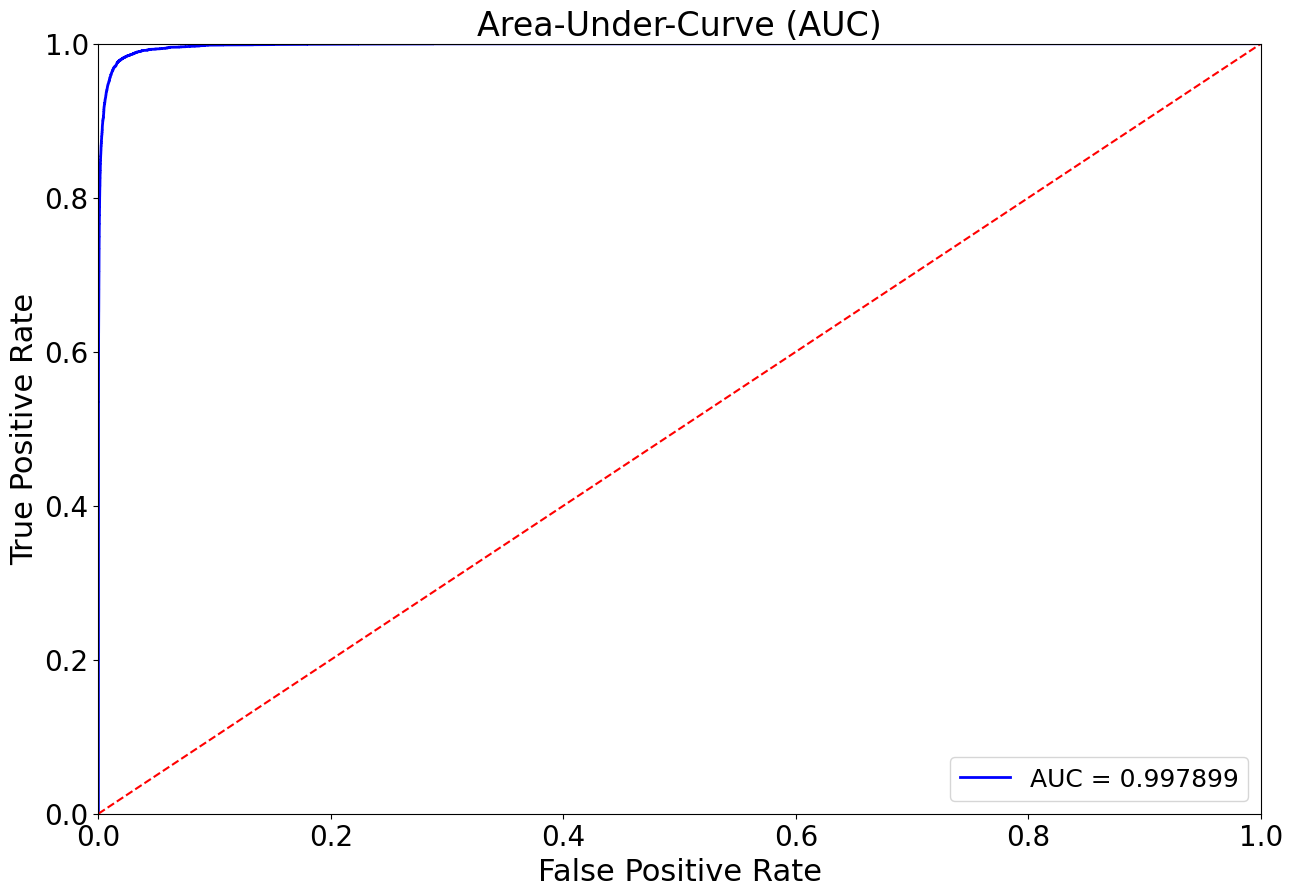

In [102]:
import sklearn.metrics as metrics
probs = model.predict_proba(X_eval)
preds = probs[:,1]
fpr, tpr, threshold = metrics.roc_curve(y_eval, preds)
roc_auc = metrics.auc(fpr, tpr)

import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (15,10)
plt.title('Area-Under-Curve (AUC)', fontsize=24)
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.6f' % roc_auc, linewidth=2)
plt.legend(loc = 'lower right', fontsize=18)
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate', fontsize=22)
plt.xlabel('False Positive Rate', fontsize=22)
plt.xticks(fontsize=20) 
plt.yticks(fontsize=20) 
plt.show()

In [72]:
print(model.get_best_score())
print(model.get_all_params())


{'learn': {'Accuracy:use_weights=true': 0.9957863813352492, 'Logloss:use_weights=false': 0.023145806346000768, 'Logloss:use_weights=true': 0.019091759554671198, 'Logloss': 0.019091759554671198, 'Accuracy:use_weights=false': 0.9920380341390767, 'AUC': 0.9996895236529444}}
{'nan_mode': 'Min', 'eval_metric': 'Logloss', 'iterations': 1000, 'sampling_frequency': 'PerTree', 'leaf_estimation_method': 'Newton', 'od_pval': 0, 'random_score_type': 'NormalWithModelSizeDecrease', 'grow_policy': 'SymmetricTree', 'penalties_coefficient': 1, 'boosting_type': 'Plain', 'model_shrink_mode': 'Constant', 'feature_border_type': 'GreedyLogSum', 'bayesian_matrix_reg': 0.10000000149011612, 'eval_fraction': 0, 'force_unit_auto_pair_weights': False, 'l2_leaf_reg': 3, 'random_strength': 1, 'od_type': 'IncToDec', 'rsm': 1, 'boost_from_average': False, 'model_size_reg': 0.5, 'pool_metainfo_options': {'tags': {}}, 'subsample': 0.800000011920929, 'use_best_model': False, 'od_wait': 20, 'class_names': [False, True], 

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36],
 [Text(0, 0, 'Lb_MAXDOCA'),
  Text(0, 1, 'L_BPVDIRA'),
  Text(0, 2, 'L_END_VY'),
  Text(0, 3, 'L_CHI2'),
  Text(0, 4, 'L_P'),
  Text(0, 5, 'L_END_VX'),
  Text(0, 6, 'pim_ETA'),
  Text(0, 7, 'p_ETA'),
  Text(0, 8, 'L_BPVIPCHI2'),
  Text(0, 9, 'L_BPVIP'),
  Text(0, 10, 'xi_LP'),
  Text(0, 11, 'Jpsi_MAXDOCA'),
  Text(0, 12, 'mup_PID_MU'),
  Text(0, 13, 'p_P'),
  Text(0, 14, 'Lb_CHI2'),
  Text(0, 15, 'p_PID_P'),
  Text(0, 16, 'L_END_VZ'),
  Text(0, 17, 'pim_PT'),
  Text(0, 18, 'Lb_P'),
  Text(0, 19, 'Jpsi_PT'),
  Text(0, 20, 'xi_LbP'),
  Text(0, 21, 'Lb_PT'),
  Text(0, 22, 'Lb_ETA'),
  Text(0, 23, 'p_PT'),
  Text(0, 24, 'Jpsi_ETA'),
  Text(0, 25, 'Lb_BPVVDRHO'),
  Text(0, 26, 'pim_GHOSTPROB'),
  Text(0, 27, 'L_END_VRHO'),
  Text(0, 28, 'Lb_MINIPCHI2'),
  Text(0, 29, 'p_GHOSTPROB')

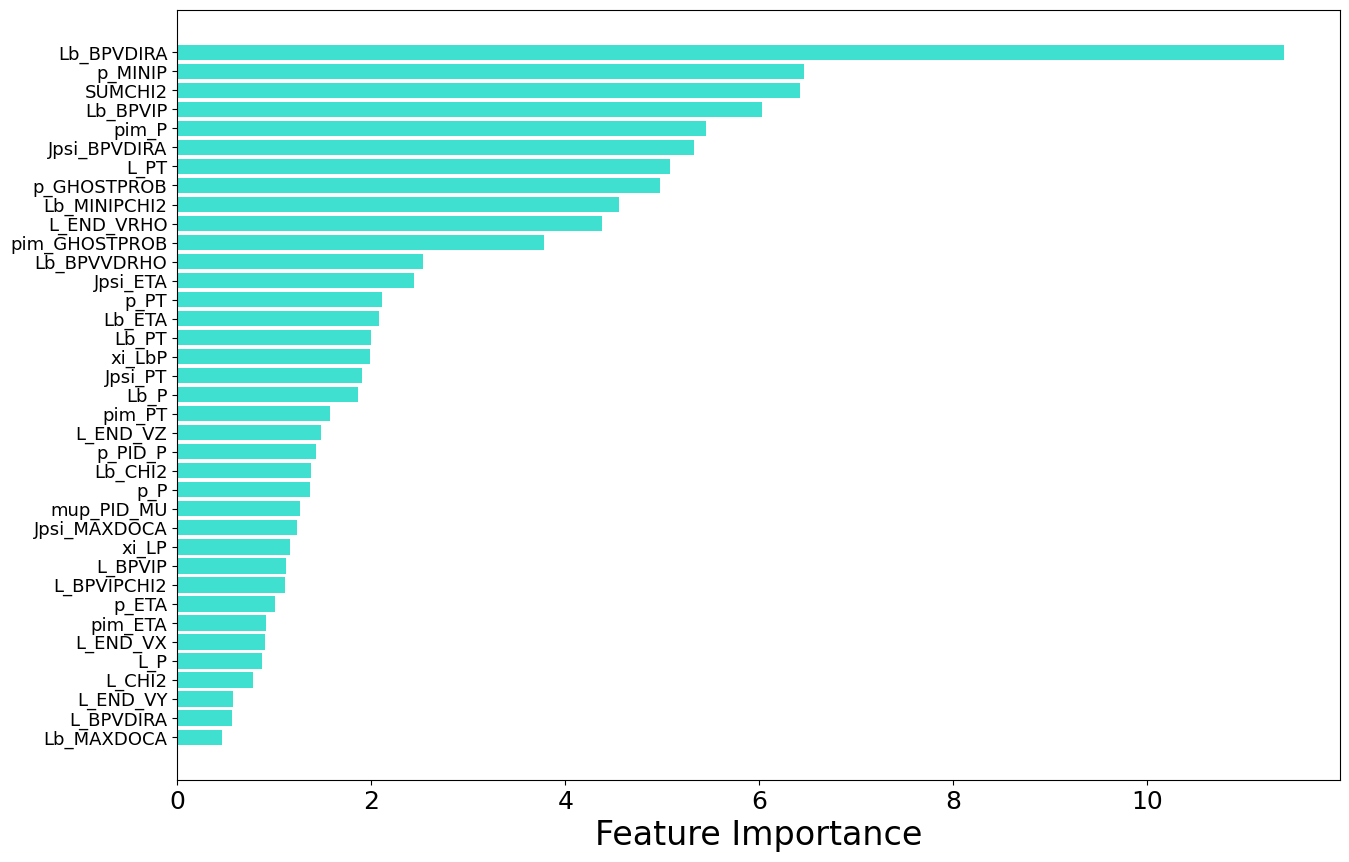

In [115]:
sorted_feature_importance = model.feature_importances_.argsort()
plt.rcParams["figure.figsize"] = (15,10)
plt.barh(X_eval.columns[sorted_feature_importance], 
        model.feature_importances_[sorted_feature_importance], 
        color='turquoise')
plt.xlabel("Feature Importance", fontsize=24)  # Ajusta el tamaño de fuente de las etiquetas en el eje y
# plt.title("Feature Importance", fontsize=24)
plt.xticks(fontsize=18)  # Ajusta el tamaño de fuente de las marcas en el eje x
plt.yticks(fontsize=13)  # Ajusta el tamaño de fuente de las etiquetas en el eje y

In [74]:
signal_MVA_prob_eval = model.predict_proba(X_eval_copy)
signal_MVA_probs = [1 - i[0] for i in signal_MVA_prob_eval]
X_eval_copy['signal_MVA'] = signal_MVA_probs

signal_MVA_prob_tr = model.predict_proba(X_tr_copy)
signal_MVA_probs = [1 - i[0] for i in signal_MVA_prob_tr]
X_tr_copy['signal_MVA'] = signal_MVA_probs

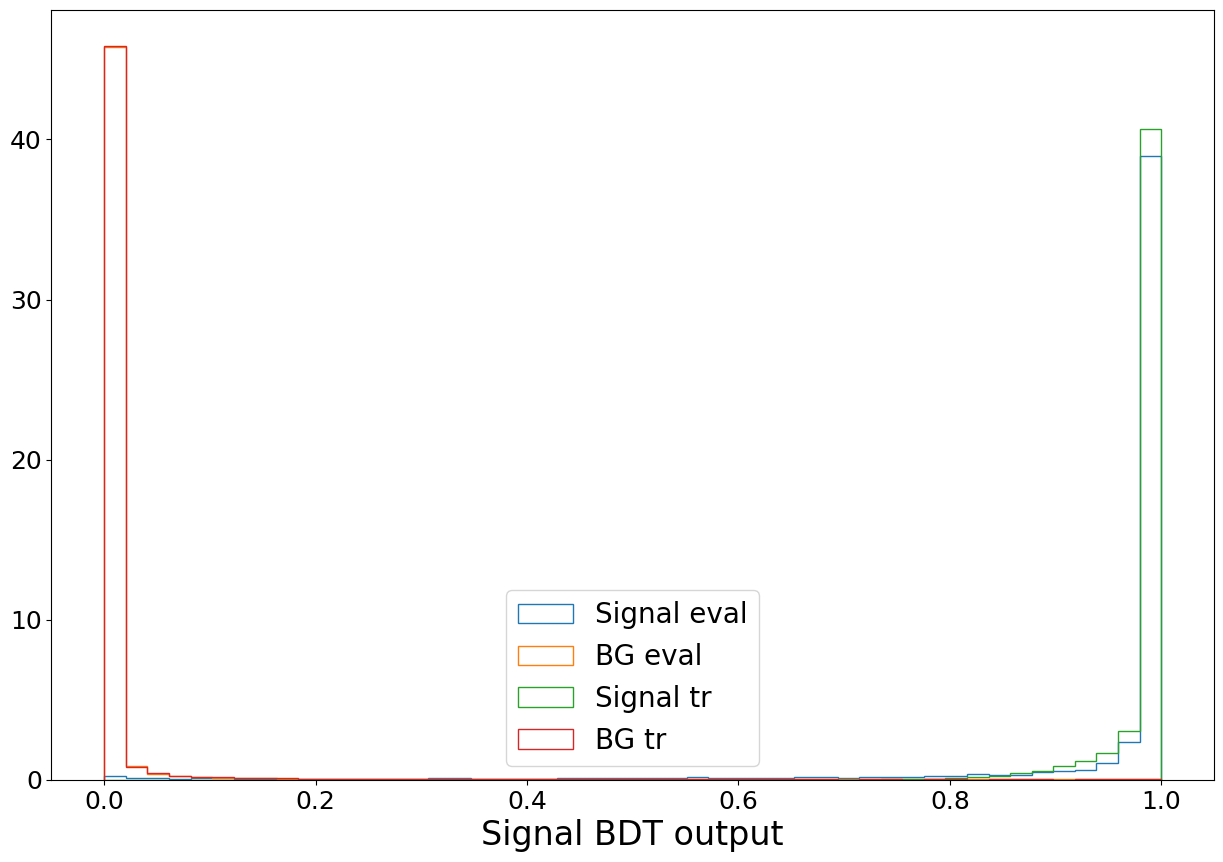

In [116]:
fig, ax = plt.subplots()

density = True

variable = 'signal_MVA'

bins = np.linspace(0,1,50)

n_sig,bins_sig, _ = ax.hist(X_eval_copy.query(f'SIGNAL')[variable], bins=bins, linewidth=1 ,label="Signal eval",histtype='step',density=density)
n_bg,bins_bg, _ = ax.hist(X_eval_copy.query(f'not SIGNAL')[variable], bins=bins, linewidth=1 ,label="BG eval",histtype='step',density=density)

ax.hist(X_tr_copy.query(f'SIGNAL')[variable], bins=bins, linewidth=1 ,label="Signal tr",histtype='step',density=density)
ax.hist(X_tr_copy.query(f'not SIGNAL')[variable], bins=bins, linewidth=1 ,label="BG tr",histtype='step',density=density)

ax.legend(fontsize=20)  # Ajusta el tamaño de fuente de la leyenda
ax.set_xlabel("Signal BDT output", fontsize=24)  # Ajusta el tamaño de fuente del eje x
plt.rcParams["figure.figsize"] = (15,10)
# Ajusta el tamaño de fuente de las marcas en los ejes x e y
# ax.tick_params(axis='both', which='major', labelsize=18)
plt.xticks(fontsize=18)  # Ajusta el tamaño de fuente de las marcas en el eje x
plt.yticks(fontsize=18)  # Ajusta el tamaño de fuente de las etiquetas en el eje y

plt.show()

In [76]:
model.save_model('new_BDT_4',
           format="cbm",
           export_parameters=None,
           pool=None)

In [77]:
for SIGNAL in [True, False]:
    print(f'SIGNAL == {SIGNAL}', len(new_training.query(f'(SIGNAL == {SIGNAL})')))

SIGNAL == True 28196
SIGNAL == False 483906


In [78]:
prob = model.predict_proba(data24_selected)
print(prob)

signal_MVA_prob_eval = prob
signal_MVA_probs = [1 - i[0] for i in signal_MVA_prob_eval]
data24_selected['prob'] = signal_MVA_probs

[[9.39504563e-01 6.04954370e-02]
 [9.99999997e-01 3.36268045e-09]
 [9.99676287e-01 3.23712607e-04]
 ...
 [9.99997911e-01 2.08910789e-06]
 [9.43216299e-02 9.05678370e-01]
 [1.95291920e-01 8.04708080e-01]]


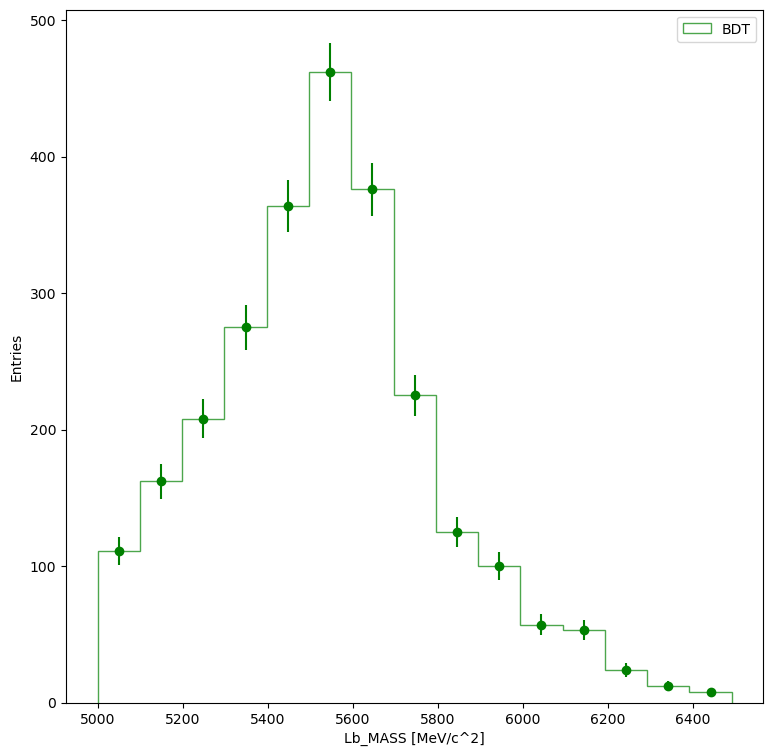

In [80]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Create the figure and axes
fig, axes = plt.subplots()

# Plot histograms
hist1, bins1, _ = axes.hist(data24_selected.query('(prob > 0.99)')['Lb_MASS'], bins=15, label='BDT', color='green', alpha=0.7, histtype='step')
# hist2, bins2, _ = axes.hist(signal_data.query('(prob2 > 0.99)')['Lb_MASS'], bins=15, label='MultiClass', color='orange', alpha=0.7, histtype='step')

# Calculate the bin centers for the error bars
bin_centers1 = 0.5 * (bins1[1:] + bins1[:-1])
# bin_centers2 = 0.5 * (bins2[1:] + bins2[:-1])

# Plot error bars for the first histogram
axes.errorbar(
    bin_centers1,
    hist1,
    yerr=np.sqrt(hist1),
    fmt='o',
    color='green',
    # label='Binary Data',
    drawstyle='steps-mid'
)

# # Plot error bars for the second histogram
# axes.errorbar(
#     bin_centers2,
#     hist2,
#     yerr=np.sqrt(hist2),
#     fmt='o',
#     color='orange',
#     # label='MultiClass Data',
#     drawstyle='steps-mid'
# )

# Set labels and legend
plt.xlabel('Lb_MASS [MeV/c^2]')
plt.ylabel('Entries')
plt.legend()

# Display the plot
plt.show()
